
 Electricity Consumption Anomaly Detection

### Project Objective
Detect unusual electricity consumption patterns using machine learning, with **Isolation Forest** as the main anomaly detection model. The project also compares detected anomalies with a 24-hour rolling baseline for contextual interpretation.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# Load dataset
df = pd.read_csv("electricity-usage.csv")

print("First 5 rows:")
display(df.head())

print("\nDataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

First 5 rows:


,DateTime,Consumption kWh,Off-peak,Mid-peak,On-peak
0,11/25/2011 01:00:00,0.39,1,0,0
1,11/25/2011 02:00:00,0.33,1,0,0
2,11/25/2011 03:00:00,0.27,1,0,0
3,11/25/2011 04:00:00,0.29,1,0,0
4,11/25/2011 05:00:00,0.29,1,0,0



Dataset shape: (2712, 5)

Column names:
['DateTime', 'Consumption kWh', 'Off-peak', 'Mid-peak', 'On-peak']


2. Data Preprocessing

In [61]:
# Convert DateTime to datetime format
df["DateTime"] = pd.to_datetime(df["DateTime"])

# Sort chronologically
df = df.sort_values("DateTime").reset_index(drop=True)

print("Missing values before preprocessing:")
print(df.isnull().sum())

# Remove rows where the target consumption value is missing
df = df.dropna(subset=["Consumption kWh"]).copy()

print("\nDataset shape after preprocessing:", df.shape)

Missing values before preprocessing:
DateTime           0
Consumption kWh    0
Off-peak           0
Mid-peak           0
On-peak            0
dtype: int64

Dataset shape after preprocessing: (2712, 5)


3. Exploratory Data Analysis (EDA)

In [62]:
print(df.describe())

                            DateTime  Consumption kWh     Off-peak  \
count                           2712      2712.000000  2712.000000   
mean   2012-01-20 11:33:09.823009024         0.445951     0.659292   
min              2011-11-25 00:00:00         0.120000     0.000000   
25%              2011-12-23 05:45:00         0.290000     0.000000   
50%              2012-01-20 11:30:00         0.340000     1.000000   
75%              2012-02-17 17:15:00         0.430000     1.000000   
max              2012-03-17 01:00:00         5.450000     1.000000   
std                              NaN         0.453289     0.474035   

          Mid-peak      On-peak  
count  2712.000000  2712.000000  
mean      0.170354     0.170354  
min       0.000000     0.000000  
25%       0.000000     0.000000  
50%       0.000000     0.000000  
75%       0.000000     0.000000  
max       1.000000     1.000000  
std       0.376013     0.376013  


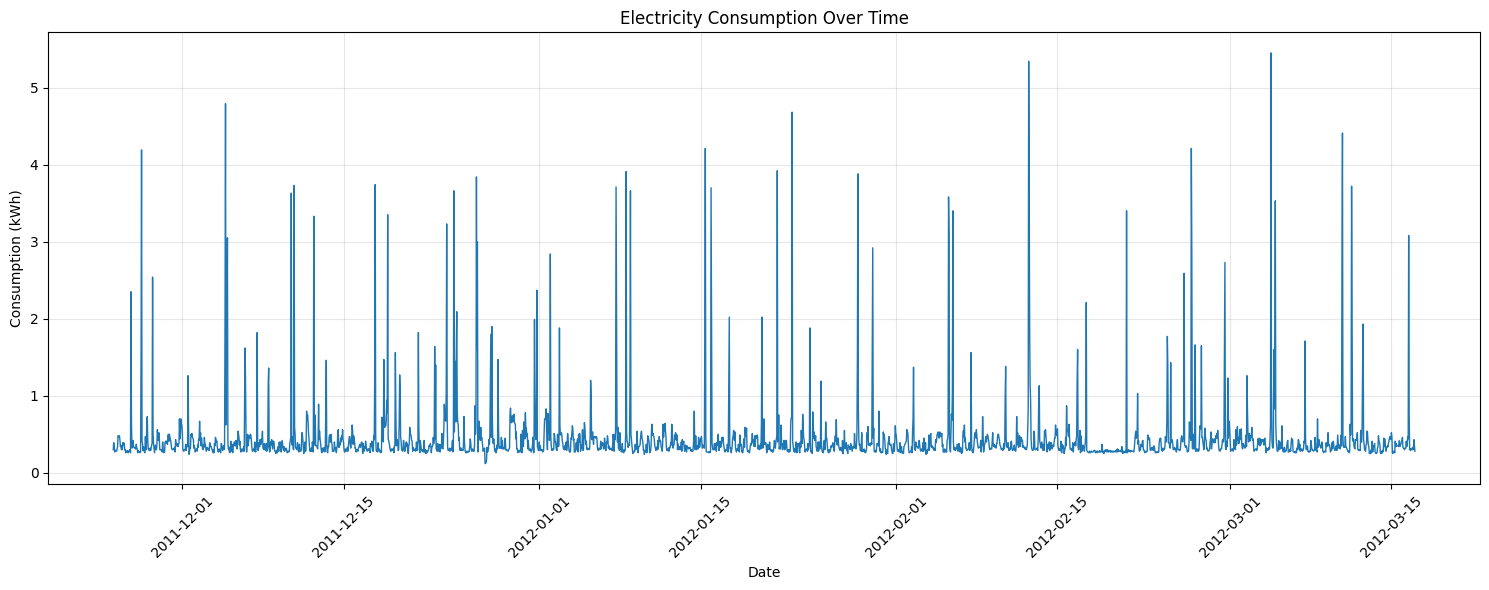

In [63]:
plt.figure(figsize=(15, 6))
plt.plot(df["DateTime"], df["Consumption kWh"], linewidth=1)
plt.xlabel("Date")
plt.ylabel("Consumption (kWh)")
plt.title("Electricity Consumption Over Time")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

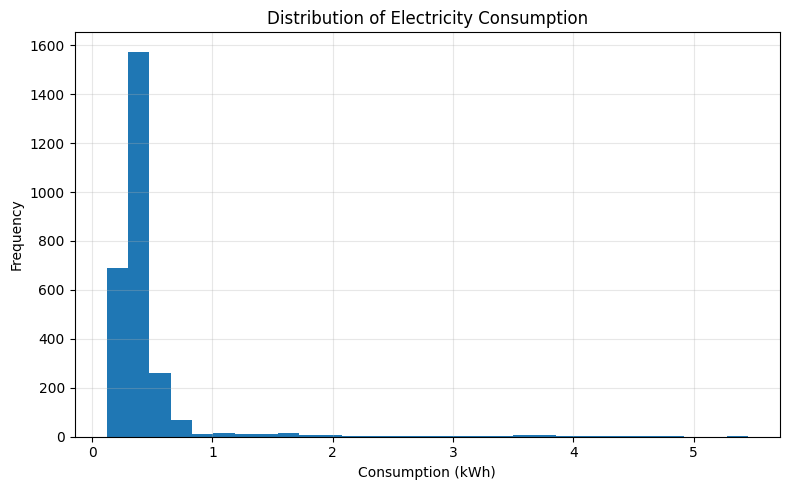

In [64]:
plt.figure(figsize=(8, 5))
plt.hist(df["Consumption kWh"], bins=30)
plt.xlabel("Consumption (kWh)")
plt.ylabel("Frequency")
plt.title("Distribution of Electricity Consumption")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

4. Time-Based Feature Engineering

The hour and day-of-week are represented using sine/cosine features so that cyclical relationships are preserved (for example, 23:00 is close to 00:00).

In [65]:
df["Hour"] = df["DateTime"].dt.hour
df["Day"] = df["DateTime"].dt.day
df["DayOfWeek"] = df["DateTime"].dt.dayofweek
df["Month"] = df["DateTime"].dt.month

# Cyclical time features
df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)
df["Day_sin"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
df["Day_cos"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

print(df[["DateTime", "Consumption kWh", "Hour", "DayOfWeek", "Hour_sin", "Hour_cos", "Day_sin", "Day_cos"]].head())

             DateTime  Consumption kWh  Hour  DayOfWeek  Hour_sin  Hour_cos  \
0 2011-11-25 00:00:00             0.30     0          4  0.000000  1.000000   
1 2011-11-25 01:00:00             0.39     1          4  0.258819  0.965926   
2 2011-11-25 02:00:00             0.33     2          4  0.500000  0.866025   
3 2011-11-25 03:00:00             0.27     3          4  0.707107  0.707107   
4 2011-11-25 04:00:00             0.29     4          4  0.866025  0.500000   

    Day_sin   Day_cos  
0 -0.433884 -0.900969  
1 -0.433884 -0.900969  
2 -0.433884 -0.900969  
3 -0.433884 -0.900969  
4 -0.433884 -0.900969  


5. Feature Selection and Scalin

In [66]:
features = [
    "Consumption kWh",
    "Hour_sin",
    "Hour_cos",
    "Day_sin",
    "Day_cos",
    "Month"
]

X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features used for anomaly detection:")
print(features)

Features used for anomaly detection:
['Consumption kWh', 'Hour_sin', 'Hour_cos', 'Day_sin', 'Day_cos', 'Month']


10. Anomaly Score Visualization

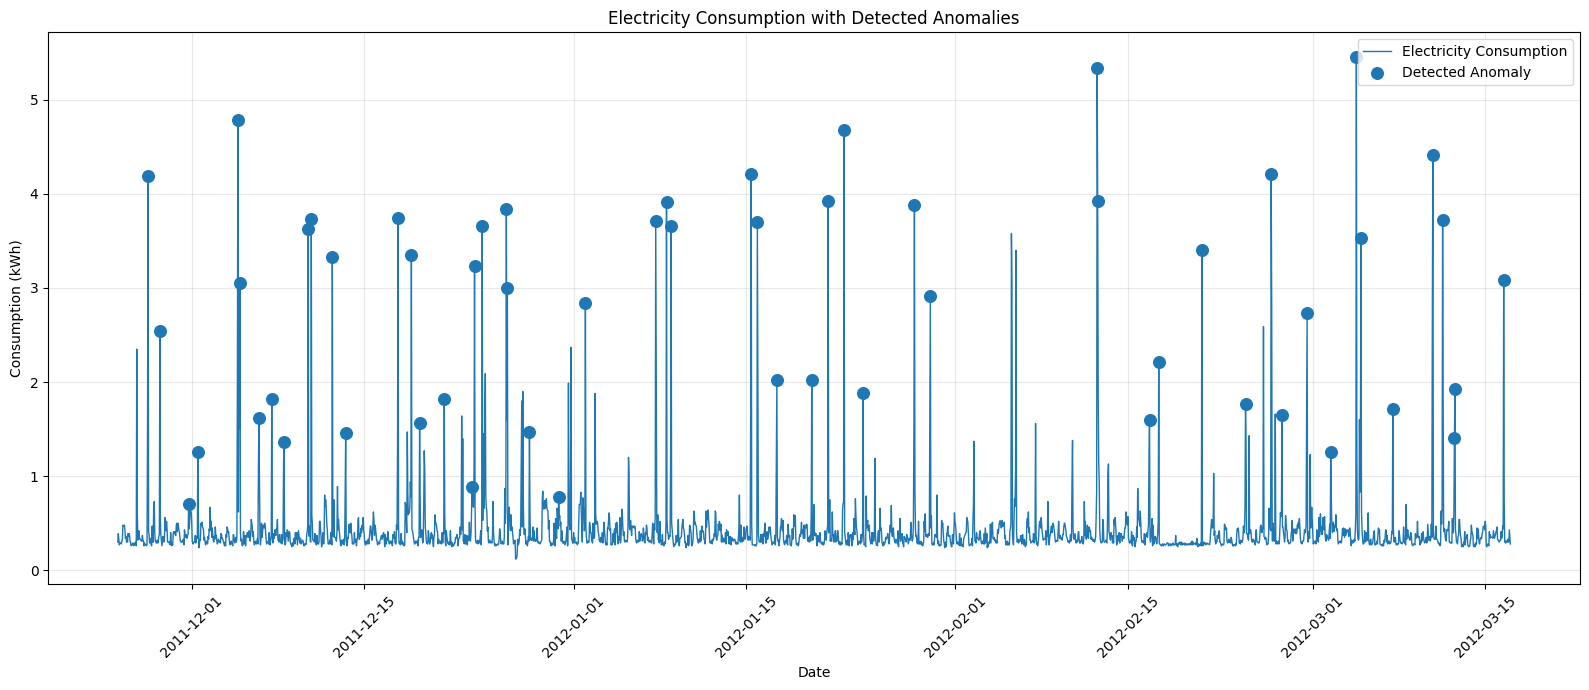

In [69]:
plt.figure(figsize=(16,7))

plt.plot(
    df["DateTime"],
    df["Consumption kWh"],
    label="Electricity Consumption",
    linewidth=1
)

plt.scatter(
    anomalies["DateTime"],
    anomalies["Consumption kWh"],
    s=70,
    label="Detected Anomaly",
    zorder=5
)

plt.xlabel("Date")
plt.ylabel("Consumption (kWh)")
plt.title("Electricity Consumption with Detected Anomalies")

plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()